# SHAP Explainability for Probability of Default Model

## Objective

This notebook explains the predictions of the LightGBM Probability of Default model using SHAP values.

SHAP helps identify which borrower and loan features have the strongest influence on predicted default risk.

The goal is to make the model more interpretable for credit risk analysis.

In [3]:
import pandas as pd
import numpy as np 
import shap
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 150)

## Import Processed Data

The processed training and testing datasets created in the previous Probability of Default modeling notebook are imported.

These datasets already include:
- missing value treatment
- categorical encoding
- numerical and categorical feature combination
- train-test split

The model comparison results are also imported to confirm the best-performing model.

In [5]:
# Import processed data from Notebook 04

X_train = pd.read_pickle("../data/X_train_processed.pkl")
X_test = pd.read_pickle("../data/X_test_processed.pkl")

y_train = pd.read_pickle("../data/y_train_pd_model.pkl")
y_test = pd.read_pickle("../data/y_test_pd_model.pkl")

results_df = pd.read_csv("../data/pd_model_results.csv")

print(X_train.shape)
print(X_test.shape)
results_df

(160000, 224)
(40000, 224)


,model,accuracy,precision,recall,f1_score,roc_auc
0,LightGBM,0.69605,0.391840,0.674266,0.495644,0.762462
1,Random Forest Classifier,0.65680,0.357193,0.687133,0.470043,0.732993
2,Logistic Regression,0.60865,0.299563,0.573025,0.393444,0.635850


## Rebuild the Best Performing Model

Based on previous model comparison, LightGBM had the strongest ROC-AUC performance.

The LightGBM model is recreated using the same modeling configuration so that SHAP can be used to explain its predictions.

In [7]:
lgbm_model = LGBMClassifier(
    learning_rat=0.05,
    n_estimator=200,
    max_depth=8,
    max_bin=255,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Create Sample for SHAP Analysis

SHAP can be computationally expensive on large datasets.

A sample of 5,000 test records is selected to make explainability analysis faster while still preserving meaningful model interpretation.

In [8]:
X_test_sample = X_test.sample(n=5000, random_state=42)

print(X_test_sample.shape)

(5000, 224)


## Create SHAP Explainer

TreeExplainer is used because LightGBM is a tree-based model.

SHAP calculates how much each feature contributes to moving a prediction higher or lower compared to the model’s baseline prediction.

In [38]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_sample)

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [39]:
print(type(shap_values))
print(np.array(shap_value_to_plot).shape)

<class 'numpy.ndarray'>
(5000, 224)


## SHAP Feature Importance - Bar Plot

The SHAP bar plot shows the top features ranked by average absolute SHAP value.

Features with higher mean absolute SHAP values have greater overall influence on the model's predictions.

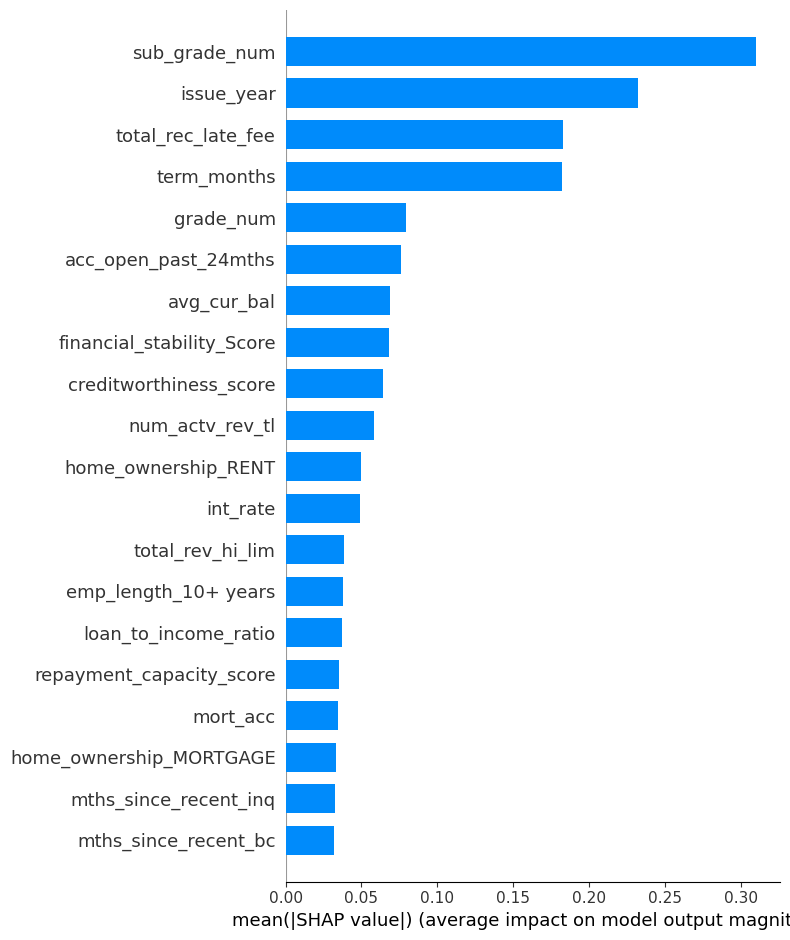

In [40]:
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=20)

## SHAP Summary Plot

The SHAP summary plot shows both feature importance and direction of impact.

It helps understand:
- which features are most important
- whether high or low feature values increase default risk
- how individual variables influence model predictions

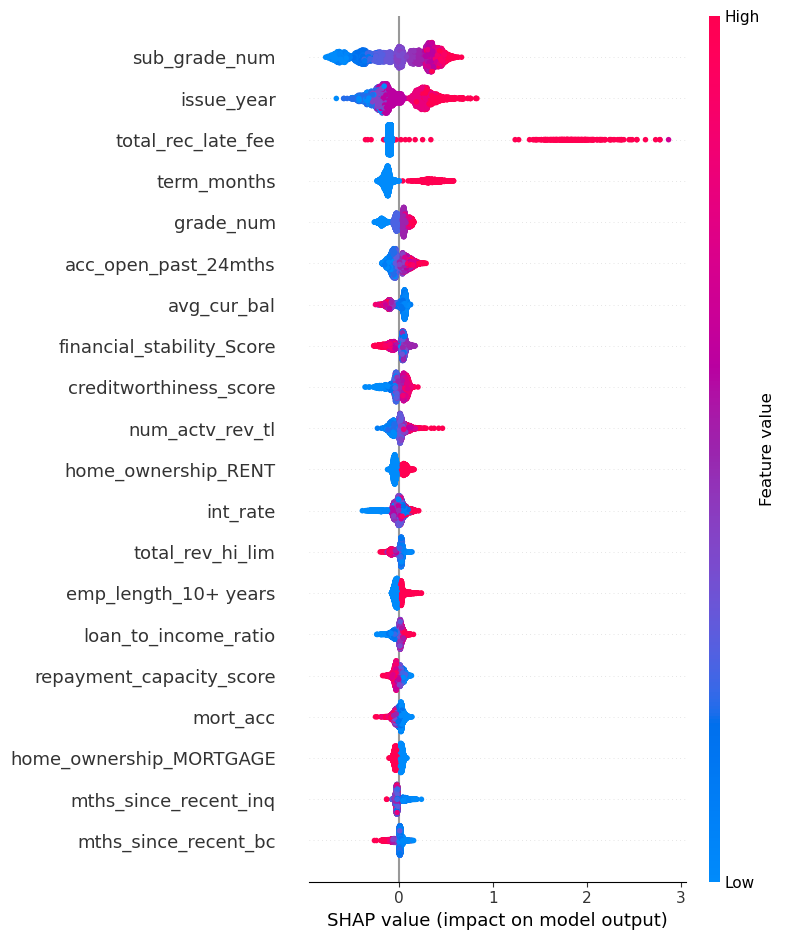

In [47]:
shap.summary_plot(shap_values, X_test_sample, max_display=20)

## Create SHAP Feature Importance Table

A feature importance table is created using mean absolute SHAP values.

This table provides a structured ranking of the most influential variables in the Probability of Default model.

In [48]:
shap_importance = pd.DataFrame(
    {
        'feature':X_test_sample.columns, 
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }
).sort_values('mean_abs_shap', ascending=False)

In [49]:
shap_importance.head(20)

,feature,mean_abs_shap
77,sub_grade_num,0.310458
58,issue_year,0.232436
14,total_rec_late_fee,0.182664
55,term_months,0.182460
76,grade_num,0.079077
20,acc_open_past_24mths,0.076200
21,avg_cur_bal,0.068816
92,financial_stability_Score,0.068480
91,creditworthiness_score,0.064170
35,num_actv_rev_tl,0.058122


## Save SHAP Feature Importance

The SHAP feature importance output is saved as a CSV file for later use.

This file can support:
- model documentation
- risk reporting
- feature selection
- borrower risk interpretation

In [50]:
shap_importance.to_csv('../data/shap_feature_importance.csv', index=False)

# Conclusion

This notebook used SHAP to explain the LightGBM Probability of Default model.

Key takeaways:
- SHAP improves interpretability of machine learning models.
- The most influential features include loan grade, sub-grade, issue year, term, repayment behavior, and borrower financial stability variables.
- SHAP helps explain both global feature importance and individual prediction behavior.
- Model explainability is especially important in credit risk because lending decisions should be transparent and defensible.

The SHAP output can be used in later stages for borrower profiling, risk segmentation, and model governance documentation.